In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats  #contains tools for statistics and probability

df = pd.read_csv("/Users/phankimsie/Documents/CamTech/Practical/auto mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [15]:
# Size of the file and a check that our variable has no missing values.
print("Rows, columns:", df.shape)
print("Missing values in mpg:", df["mpg"].isna().sum())

Rows, columns: (398, 9)
Missing values in mpg: 0


Population size N = 398
Population mean    = 23.51 mpg
Population st.dev = 7.82 mpg


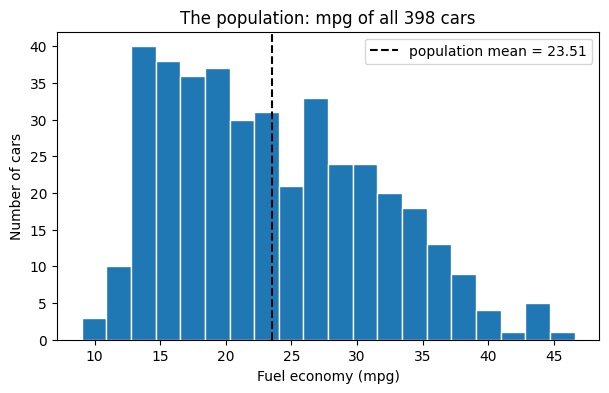

In [16]:
population = df["mpg"]
N = len(population)
mu = population.mean()
sigma = population.std()

print("Population size N =", N)
print(f"Population mean    = {mu:.2f} mpg")
print(f"Population st.dev = {sigma:.2f} mpg")

# A picture of the population of individual cars.
plt.figure(figsize=(7, 4))
plt.hist(population, bins=20, edgecolor="white")
plt.axvline(mu, color="black", linestyle="--", label=f"population mean = {mu:.2f}")
plt.xlabel("Fuel economy (mpg)")
plt.ylabel("Number of cars")
plt.title("The population: mpg of all 398 cars")
plt.legend()
plt.show()

In [17]:
sample = population.sample(n=30, random_state=42) #42 is seed for the random number generator.
n = len(sample)
print("Sample size n =", n)

x_bar = sample.mean()
s = sample.std()

# The same s, written exactly as in the formula, to see that they agree.
s_formula = np.sqrt(((sample - x_bar) ** 2).sum() / (n - 1))


print(f"\nSample mean              x_bar = {x_bar:.2f} mpg")
print(f"Sample st.dev (n-1)      s     = {s:.2f} mpg")
print(f"Same s from the formula        = {s_formula:.2f} mpg")

Sample size n = 30

Sample mean              x_bar = 22.57 mpg
Sample st.dev (n-1)      s     = 8.11 mpg
Same s from the formula        = 8.11 mpg


In [18]:
# The standard error of the sample mean, estimating sigma by s (sigma is unknown in practice).
se = sample.std() / np.sqrt(len(sample))
print(f"{se}")

# How does SE change with n? We keep s fixed at our sample value and only change n.
sizes = [10, 30, 50, 100,1000,100000,10000000]
se_table = pd.DataFrame({
    "n": sizes,
    "SE = s/sqrt(n)": [s / np.sqrt(k) for k in sizes]
})
display(se_table.round(3))


1.4812867193178996


,n,SE = s/sqrt(n)
0,10,2.566
1,30,1.481
2,50,1.147
3,100,0.811
4,1000,0.257
5,100000,0.026
6,10000000,0.003


In [19]:
#confidence interval 

alpha = 0.05
dof = n-1

t_critical = stats.t.ppf(1-alpha/2,dof)   #stats.t → t-distribution, ppf(...) → finds critical value
lower_interval = x_bar - t_critical * se
upper_interval = x_bar + t_critical * se

print(f"the confidence interval is ({lower_interval:.3f},{upper_interval:.3f})")

# Verification: let SciPy build the same interval.
# loc = center of the interval (the point estimate), scale = standard error.
ci_scipy = stats.t.interval(0.95, dof, loc=x_bar, scale=se)
print(f"\nSciPy CI: ({ci_scipy[0]:.2f}, {ci_scipy[1]:.2f}) mpg")

the confidence interval is (19.540,25.600)

SciPy CI: (19.54, 25.60) mpg


Proportion of the 1000 intervals that contain mu = 94.2%


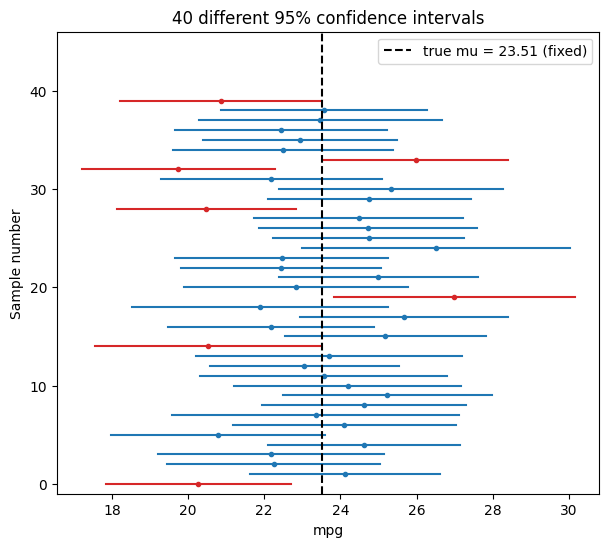

In [20]:
# DEMONSTRATION: repeat "take a sample -> build a 95% CI" 1000 times.
sim_means = []
sim_lowers = []
sim_uppers = []

for i in range(1000):
    # A fresh random sample of 30 cars. replace=True makes the 30 draws independent,
    # exactly as assumed in the theory. random_state=i keeps results reproducible.
    new_sample = population.sample(n=30, replace=True, random_state=i)

    m = new_sample.mean()                        
    se_i = new_sample.std() / np.sqrt(30)       
    low, high = stats.t.interval(0.95, 29, loc=m, scale=se_i)

    sim_means.append(m)
    sim_lowers.append(low)
    sim_uppers.append(high)

sim_means = np.array(sim_means)
sim_lowers = np.array(sim_lowers)
sim_uppers = np.array(sim_uppers)

# An interval "captures" mu if mu lies between its lower and upper limits.
captures_mu = (sim_lowers <= mu) & (mu <= sim_uppers)
print(f"Proportion of the 1000 intervals that contain mu = {captures_mu.mean() * 100:.1f}%")

# Plot the first 40 intervals: blue = contains mu, red = misses mu.
plt.figure(figsize=(7, 6))
for i in range(40):
    color = "tab:blue" if captures_mu[i] else "tab:red"
    plt.plot([sim_lowers[i], sim_uppers[i]], [i, i], color=color)
    plt.plot(sim_means[i], i, "o", color=color, markersize=3)
plt.axvline(mu, color="black", linestyle="--", label=f"true mu = {mu:.2f} (fixed)")
plt.xlabel("mpg")
plt.ylabel("Sample number")
plt.title("40 different 95% confidence intervals")
plt.ylim(-1, 46)          # leave room for the legend
plt.legend(loc="upper right")
plt.show()

In [21]:
# Sample
sample = population.sample(n=30, random_state=42)

# Hypothesized population mean
mu_0 = 25

# Significance level
alpha = 0.05

# Sample statistics
n = len(sample)
x_bar = sample.mean()
sigma = population.std()

# Z statistic
z = (x_bar - mu_0) / (sigma / np.sqrt(n))

#CDF: Given a value → find the probability
#PPF: Given a probability → find the value

# Two-sided p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z))) #cdf gives the probability to the left of that Z-value under the standard normal distribution.

# Critical values
z_critical = stats.norm.ppf(1 - alpha / 2)

print(f"Sample mean = {x_bar:.4f}")
print(f"Z statistic = {z:.4f}")
print(f"Critical values = ±{z_critical:.4f}")
print(f"P-value = {p_value:.4f}")

if abs(z) > z_critical:
    print("Reject H0")
else:
    print("Fail to reject H0")

Sample mean = 22.5700
Z statistic = -1.7029
Critical values = ±1.9600
P-value = 0.0886
Fail to reject H0


In [22]:
import numpy as np
from scipy import stats

# Sample
sample = population.sample(n=30, random_state=42)

# Hypothesized population mean
mu_0 = 25

# Significance level
alpha = 0.05

# Sample statistics
n = len(sample)
x_bar = sample.mean()
s = sample.std(ddof=1)

# t statistic
t = (x_bar - mu_0) / (s / np.sqrt(n))

# Degrees of freedom
dof = n - 1

# Two-sided p-value
p_value = 2 * (1 - stats.t.cdf(abs(t), dof))

# Critical value
t_critical = stats.t.ppf(1 - alpha / 2, dof)

print(f"Sample mean = {x_bar:.4f}")
print(f"t statistic = {t:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"Critical values = ±{t_critical:.4f}")
print(f"P-value = {p_value:.4f}")

if abs(t) > t_critical:
    print("Reject H0")
else:
    print("Fail to reject H0")

Sample mean = 22.5700
t statistic = -1.6405
Degrees of freedom = 29
Critical values = ±2.0452
P-value = 0.1117
Fail to reject H0
